<a href="https://colab.research.google.com/github/Mounia-Agronomist-Datascientist/AT-T_project/blob/main/1_AT_T_project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **________ AT&T project ________** #

*The goal of this project is to build a spam detector, that can automatically flag spams as they come based solely on the sms' content.*

## **I. EDA**

###  **0. Configuration & Drive setup**

The following code performs setup actions that are necessary for every session:



* **drive.mount():** Connects Drive to the temporary Colab machine.
* **os.chdir(PROJECT_PATH)**: Moves Python session into the project folder.
* **sys.path.append('src'):** Allows us to import our .py files (for instance : custumed functions).

This cell must be run in the first cell of every notebook, every time a session is started.

In [1]:
#  --------------  CODE TO MOUNT DRIVE AND SET WORKING DIRECTORY   --------------

from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your project path
PROJECT_PATH = '/content/drive/MyDrive/Colab_Projects/AT-T_project'

# 3. Change current directory to the project path
os.chdir(PROJECT_PATH)

# 4. Add the 'src' directory to Python's system path

import sys
if 'src' not in sys.path:
    sys.path.append('src')

Mounted at /content/drive


###  **1. Libraries import**

In [2]:
import io
import os
import re
import shutil
import tarfile
import string

import tiktoken
import requests
import numpy as np
import pandas as pd

# ================ STATISTICS ===============
from scipy.stats import ttest_ind

# =============== VISUALIZATION =============
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== NLP ==================
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer


# =============== DEEP LEARNING =============
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device.")

Using cpu device.


### **2. Data import & general information on the dataset**

In [3]:
raw_df=pd.read_csv('./DATA/DATA_raw/spam.csv',encoding='latin-1')

# The file contains some specific characters that are not valid under the
# utf-8 encoding scheme so we select the 'latin-1 encoding that covers all 256 byte values.

raw_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
raw_df.shape

(5572, 5)

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
raw_df.describe(include='all')

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


This dataset contains 5 columns but only the first 2 ones will be used for this analysis. Indeed the last 3 ones contains to many NaN to have a significant meaning.

### **3. Data cleaning**

Dropping useless columns and renaming the other ones :

In [7]:
df = raw_df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df[['label', 'message']]

Check for duplicated rows:

In [8]:
duplicates = df.duplicated().sum()
print(f"There are : {duplicates} duplicated rows, this represents {round((100*duplicates/df.shape[0]),2)} % of the dataset.")

There are : 403 duplicated rows, this represents 7.23 % of the dataset.


Approximately 7.2% of the dataset is identified as duplicated. We are going to deeper investigate these duplicates :


In [9]:
# We select and order the duplicated rows:

df[df.duplicated(keep=False)].sort_values(by=["label", "message"])

,label,message
1372,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2162,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2343,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1469,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...
1778,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...
...,...,...
5035,spam,You won't believe it but it's true. It's Incre...
2832,spam,You've won tkts to the EURO2004 CUP FINAL or å...
3003,spam,You've won tkts to the EURO2004 CUP FINAL or å...
95,spam,Your free ringtone is waiting to be collected....


In [10]:
# We check that every duplicate has only one label (not both ham and spam)

df.groupby("message")["label"].nunique().value_counts()

,count
label,
1,5169


The results confirmed that there are no inconsistencies (i.e., no message labeled both as spam and ham).

In the context of natural language processing, keeping duplicated messages may introduce bias by over-representing certain texts, which can lead to overfitting and reduced generalization performance.

Therefore, we decided to remove duplicates based on the message content, keeping only unique messages in the dataset. This approach helps improve model robustness and ensures a more balanced representation of the textual data.

In [11]:
df = df.drop_duplicates(subset=["message"])

In [12]:
print(f"{len(raw_df)-len(df)} rows have been dropped.")

403 rows have been dropped.


In [13]:
print(f"The cleaned dataset has : {df.shape[0]} rows and {df.shape[1]} columns.")

The cleaned dataset has : 5169 rows and 2 columns.


### **4. Class Distribution**

***1. Class distribution of the target***

In [14]:
distribution = round(100 * df['label'].value_counts(normalize=True),2)
distribution

,proportion
label,
ham,87.37
spam,12.63


We can notice that our target variable (spam or non-spam) is **imbalanced.** It means that for evaluating our models we are going to focus more on Precision, Recall, and F1-score rather than just Accuracy. Moreover, we will potentially require sampling techniques (like oversampling (SMOTE)) or undersampling).

***2. Label Encoding***

For Machine Learning, we need to convert labels into numbers:

In [15]:
# 0 -> represents the non spam class 'ham'
# 1 -> represents the spam class  `spam`

In [16]:
df['encoded_label'] = df['label'].map({'ham': 0, 'spam': 1})

In [17]:
df.head(10)

,label,message,encoded_label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1


### **5. Message length analysis**

We are now going to check if the spam messages have specific patters. First, we will check the lenght of messages. Are spams shorter? Longer? Is there a significant difference? We can check two kind of lenghts : the number of total characters in the message and the number of words.

In [18]:
# Number of characters in the messages :
df['nb_chars'] = df['message'].apply(len)

# Number of words in the messages
df['nb_words'] = df['message'].apply(lambda x: len(x.split()))

In [19]:
df.head(5)

,label,message,encoded_label,nb_chars,nb_words
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13


In [20]:
ham_df = df[df['label'] == 'ham'].copy()
spam_df = df[df['label'] == 'spam'].copy()

In [21]:
ham_df.describe(exclude = object)

,encoded_label,nb_chars,nb_words
count,4516.0,4516.000000,4516.000000
mean,0.0,70.459256,14.134632
std,0.0,56.358207,11.116240
min,0.0,2.000000,1.000000
25%,0.0,34.000000,7.000000
50%,0.0,52.000000,11.000000
75%,0.0,90.000000,18.000000
max,0.0,910.000000,171.000000


In [22]:
spam_df.describe(exclude = object)

,encoded_label,nb_chars,nb_words
count,653.0,653.000000,653.000000
mean,1.0,137.891271,23.681470
std,0.0,30.137753,5.967672
min,1.0,13.000000,2.000000
25%,1.0,132.000000,22.000000
50%,1.0,149.000000,25.000000
75%,1.0,157.000000,28.000000
max,1.0,224.000000,35.000000


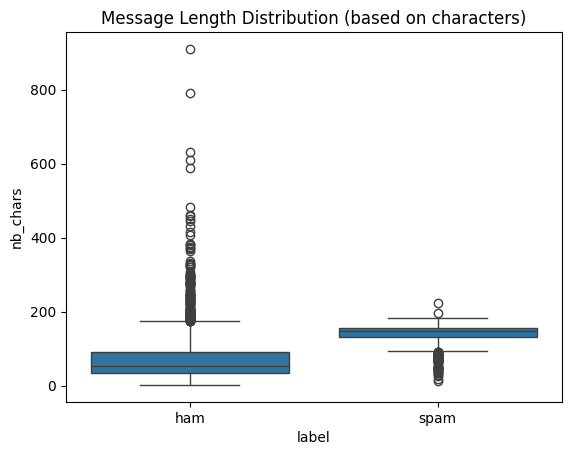

In [23]:
sns.boxplot(x="label", y="nb_chars", data=df)

plt.title("Message Length Distribution (based on characters)")
plt.show()

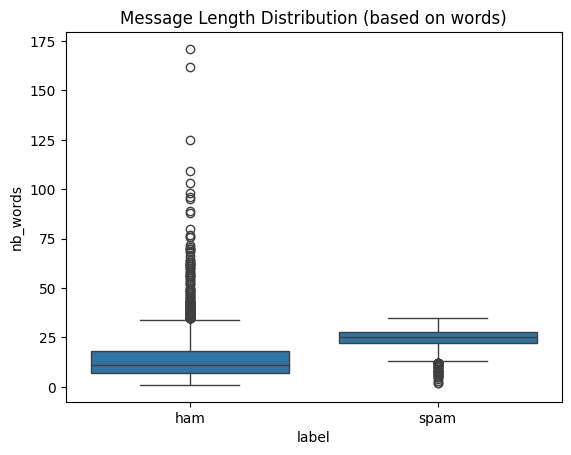

In [24]:
sns.boxplot(x="label", y="nb_words", data=df)

plt.title("Message Length Distribution (based on words)")
plt.show()

The boxplots suggests a difference in the lenghts of spam messages that seems to be longer. We need to validate this difference using a statistic test. First we can chek if the data are normally distributed:

In [25]:
from scipy.stats import shapiro

shapiro(df["nb_chars"])


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5169.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.8093064896464311), pvalue=np.float64(2.2735091279079024e-61))

Given the large sample size and the Shapiro test result (p-value < 0.05), the normality assumption is violated. Therefore, I used a non-parametric Mann-Whitney test.

In [26]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(ham_df["nb_chars"],
                            spam_df["nb_chars"])

print(p_value)

4.6033274103229373e-212


In [27]:
stat, p_value = mannwhitneyu(ham_df["nb_words"],
                            spam_df["nb_words"])
print(p_value)

6.409562529593963e-150


In both cases the p-value < 0.05 so the difference is meaningful. We can say that spam messages have generally more words and characters than ham messages.
The ham messages have on average:

*   70 characters,
*   14 words,
so they are relatively short.

Whereas spam messages have on average:

*  138 characters
*  23 words.

Lenght is a usefull feature for our analysis.



### **6. Word frequency analysis**

We have seen a significant difference between spams and hams in terms of lenght of the messages, what about the words themselves? Is there a significant difference of vocabulary used? In order to lead such an analysis, we need to apply a basic preprocessing on the text.

***1. Basic preprocess***

In [28]:
# We put the words in lower mode and remove all the punctuation

df['cleaned_message'] = df['message'].apply(lambda x: ''.join(c for c in x.lower() if c not in string.punctuation))

In [29]:
df.head()

,label,message,encoded_label,nb_chars,nb_words,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,0,29,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,0,49,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,nah i dont think he goes to usf he lives aroun...


***2. Most frequent words***

In [30]:
# We create a function for counting the words

def top_words(texts, top_n=20):
    """
    Counts the most frequent words in a series of texts.

    Arguments:
        texts (iterable): list or Series of texts
        top_n (int): number of top words to display
    """
    all_words = ' '.join(texts).split()
    counts = Counter(all_words)
    for word, count in counts.most_common(top_n):
        print(f"- {word} : {count} occurrences")


Top 15 words for the whole dataset :

In [31]:
top_words(df['cleaned_message'],15)

- i : 2116 occurrences
- to : 2068 occurrences
- you : 2032 occurrences
- a : 1288 occurrences
- the : 1228 occurrences
- u : 1001 occurrences
- and : 922 occurrences
- in : 813 occurrences
- is : 789 occurrences
- me : 738 occurrences
- my : 678 occurrences
- for : 660 occurrences
- your : 619 occurrences
- it : 571 occurrences
- of : 558 occurrences


Top 15 words for the ham messages:

In [32]:
top_words(df[df['label'] == 'ham']['cleaned_message'],15)

- i : 2075 occurrences
- you : 1773 occurrences
- to : 1474 occurrences
- the : 1047 occurrences
- a : 957 occurrences
- u : 878 occurrences
- and : 818 occurrences
- in : 751 occurrences
- me : 712 occurrences
- my : 668 occurrences
- is : 645 occurrences
- it : 546 occurrences
- of : 477 occurrences
- for : 476 occurrences
- that : 472 occurrences


Top 15 words for the spam messages:

In [33]:
top_words(df[df['label'] == 'spam']['cleaned_message'],15)

- to : 594 occurrences
- a : 331 occurrences
- call : 303 occurrences
- you : 259 occurrences
- your : 241 occurrences
- free : 188 occurrences
- for : 184 occurrences
- the : 181 occurrences
- or : 157 occurrences
- now : 156 occurrences
- 2 : 155 occurrences
- is : 144 occurrences
- txt : 126 occurrences
- u : 123 occurrences
- on : 121 occurrences


We can see that the most represented words for the whole dataset are quite close than the one from the ham messages. But it could be explained by the hight proportion of ham messages in the dataset. But what can be noticed is that the most common word is "I" whereas this pronoun in not in the list of the top 15 words of spams. Moreover, free is a word very present in spams but not in ham messages. Let's visualize the differences with wordclouds.

In [34]:
def wordcloud(text, ax, title, colormap):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colormap,
        max_words=100
    ).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold')

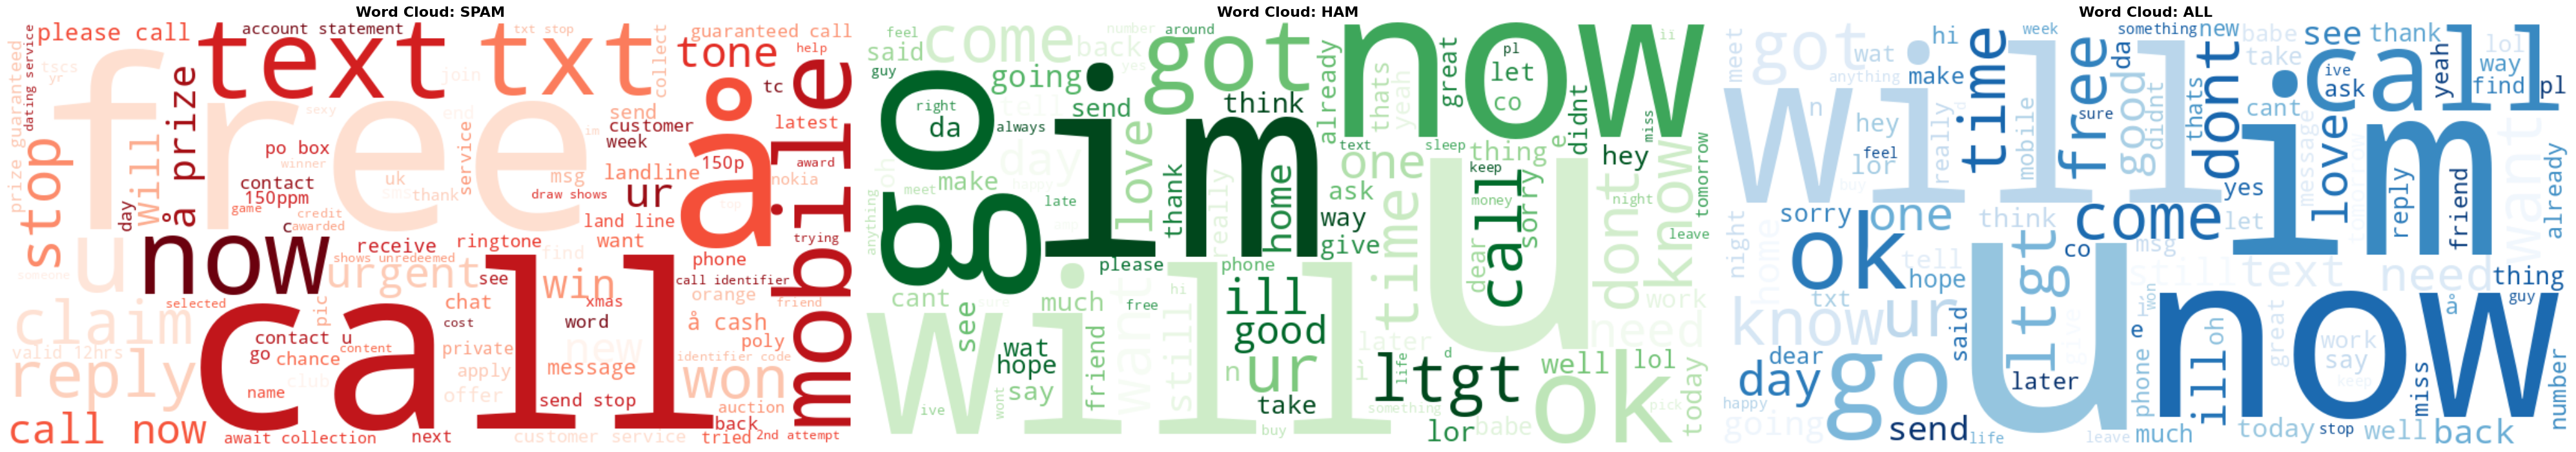

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(40, 15))

# SPAM
spam_text = ' '.join(df[df['label'] == 'spam']['cleaned_message'])
wordcloud(spam_text, axes[0], 'Word Cloud: SPAM', 'Reds')

# HAM
ham_text = ' '.join(df[df['label'] == 'ham']['cleaned_message'])
wordcloud(ham_text, axes[1], 'Word Cloud: HAM', 'Greens')

# ALL DATA
all_text = ' '.join(df['cleaned_message'])
wordcloud(all_text, axes[2], 'Word Cloud: ALL', 'Blues')

plt.tight_layout()
plt.show()

We can identify words that are frequently present in spams but rare or not present in the ham messages and ignore common words. To do so, we are using TD-IDF (TF-IDF measures how important a word is in a document relative to a corpus by combining its frequency in the document with its rarity across all documents). Here each message from the dataset represents a document.

In [36]:
# Global TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = vectorizer.fit_transform(df['cleaned_message'])
feature_names = vectorizer.get_feature_names_out()

In [37]:
# Separate Ham and Spam
mask_spam = (df['label'] == 'spam').to_numpy()
mask_ham = (df['label'] == 'ham').to_numpy()

X_spam = X[mask_spam]
X_ham = X[mask_ham]

In [38]:
# Mean TF-IDF per class
mean_spam = np.asarray(X_spam.mean(axis=0)).flatten()
mean_ham = np.asarray(X_ham.mean(axis=0)).flatten()

In [39]:
# Difference
diff = mean_spam - mean_ham
print(diff)

[ 0.00090332  0.00057116  0.00041019 ...  0.0005083   0.00047676
 -0.00064343]


For each element of the vector:


*   If the result is positif : the word is typical from Spam
*   If the result is negative : the word is typical of Ham



We need to filter the rare word to avoid noise in our result

In [40]:
word_counts = np.asarray(X.sum(axis=0)).flatten()

# We keep only non-rare words
mask = word_counts > 10

Top spam typical words:

In [41]:
top_spam_idx = diff.argsort()[::-1]

top_spam_words = [
    feature_names[i]
    for i in top_spam_idx
    if mask[i]
][:10]


print("Top SPAM words:")
for word in top_spam_words:
  print(f"   - {word}")

Top SPAM words:
   - free
   - txt
   - mobile
   - claim
   - prize
   - stop
   - reply
   - text
   - urgent
   - won


Top ham typical words

In [42]:
top_ham_idx = diff.argsort()

top_ham_words = [
    feature_names[i]
    for i in top_ham_idx
    if mask[i]
][:10]

print("Top HAM words:")
for word in top_ham_words:
  print(f"   - {word}")

Top HAM words:
   - im
   - ok
   - ltgt
   - come
   - ill
   - got
   - lor
   - home
   - going
   - like


By computing the difference of mean TF-IDF scores between spam and ham and filtering out low-frequency words, we can identify discriminative terms for each class:

| SPAM | HAM |
|---|---|
|free|im|
|txt|ok|
|mobile|ltgt|
|claim|come|
|prize|ill|
|stop|got|
|reply|lor|
|text|home|
|urgent|going|
|won|like|


### **7. Special characters analysis**

Generally, spams messages are created to be more appealing so they might use more punctuation or emogis or capital letters. Let's analyze specific characters to check if we see differences between spam and ham messages. For that, we create new columns in our dataframe.

In [45]:
# Capital letters
df['nb_capitals'] = df['message'].str.count(r'[A-Z]')
df['percent_capitals'] = df['nb_capitals'] / df['message'].str.len() * 100

# Punctuation
df['nb_exclamations'] = df['message'].str.count('!')
df['nb_punctuation'] = df['message'].str.count(r'[.,!?;:()\-"\']')

# Digits and phone numbers
df['nb_digits'] = df['message'].str.count(r'\d')
df['has_phone_number'] = df['message'].str.contains(r'\d{5,}').astype(int)

# Money symbols
df['has_money_symbol'] = df['message'].str.contains(r'[£$€]').astype(int)

# Emogis
df['nb_emojis'] = df['message'].str.count(
    r'[\U0001F1E0-\U0001F1FF'  # flags
    r'\U0001F300-\U0001F5FF'  # symbols
    r'\U0001F600-\U0001F64F'  # smileys
    r'\U0001F680-\U0001F6FF'  # transport
    r'\U0001F700-\U0001F77F'  # alchemical symbols
    r'\U0001F900-\U0001F9FF'  # supplemental symbols
    r'\U0001FA00-\U0001FAFF'  # recent emojis
    r']'
)

Now that we have all the necessary columns to evaluate the special characters, we can lead statistical analysis and compaire Spams and Hams

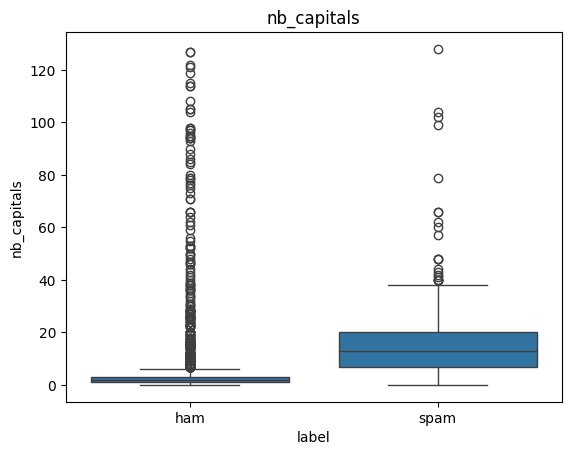

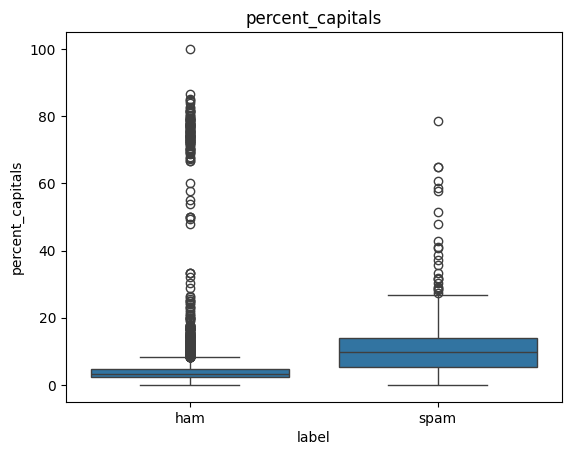

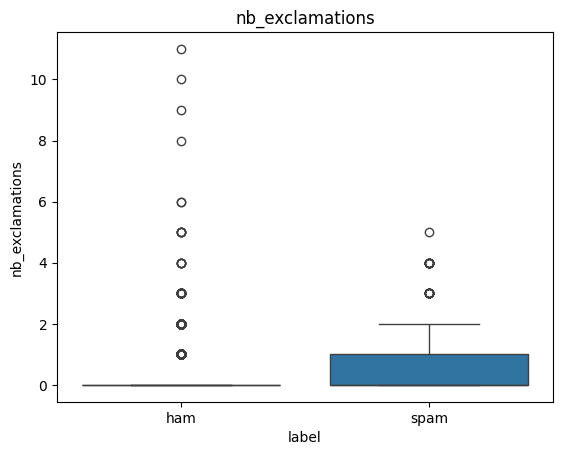

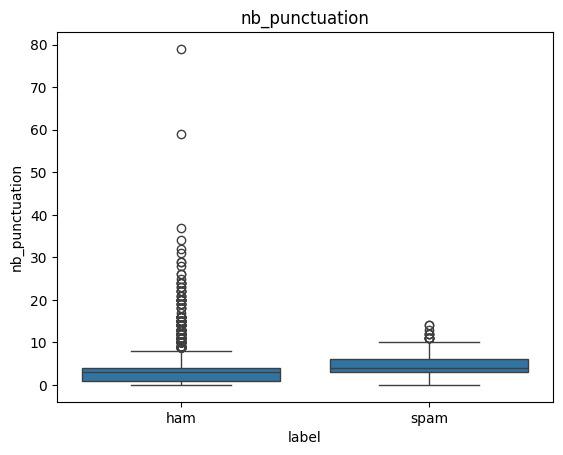

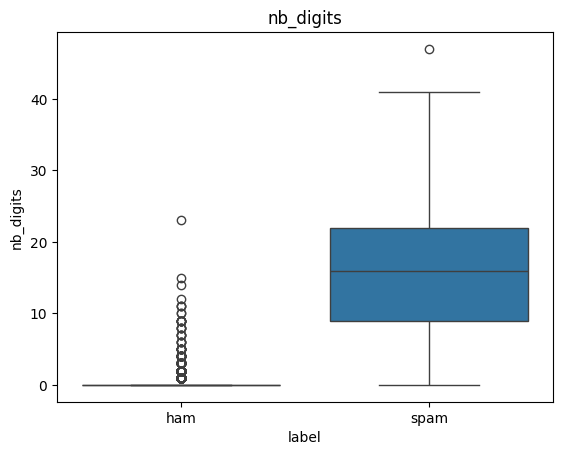

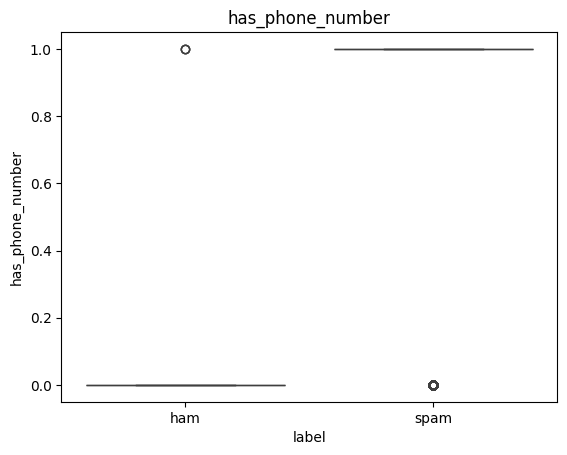

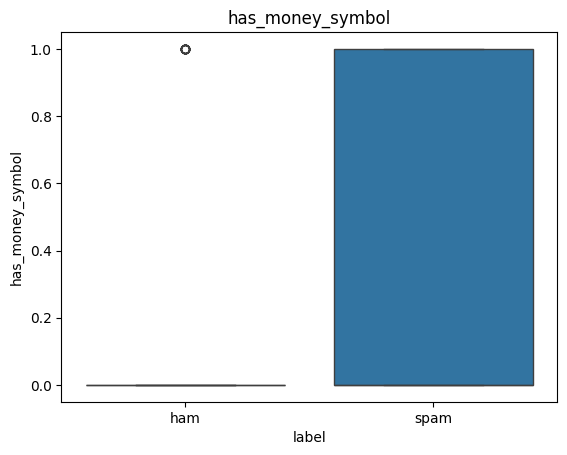

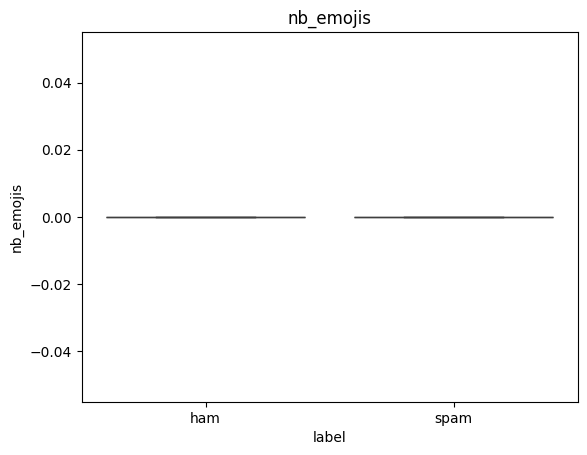

In [46]:
features = [
    'nb_capitals', 'percent_capitals',
    'nb_exclamations', 'nb_punctuation',
    'nb_digits', 'has_phone_number',
    'has_money_symbol', 'nb_emojis'
]

for col in features:
    sns.boxplot(x='label', y=col, data=df)
    plt.title(col)
    plt.show()

In [ ]:
for col in features:
    spam = df[df['label'] == 'spam'][col]
    ham = df[df['label'] == 'ham'][col]

    stat, p = ttest_ind(spam, ham, equal_var=False)
    print(f"{col}: p-value = {p}")

## **III. PREPROCESSING**

## **IV. MODELIZATION**

## **V. EVALUATION**